# 线性神经网络B
## Softmax回归
#### 分类问题
除了预测数值，机器学习还被期待用来对样本进行分类。分类即可以指我们对物品的硬性类别的区分（硬分类），也可以指我们某个物体有多少概率属于某个类别的预测（软分类），以上都属于分类问题。

假设我们获得了一个样本，样本本身是一个张量（如图片）。我们最后想把图片分类成具体的A B C…，那么我们就需要对ABC编号，比如给{A, B, C} 编号为{0, 1, 2}。这对于有自然顺序的分类（比如按年龄分类）很有益，因为这可以把分类问题尽可能地向回归问题靠近。

同时，还可以把分类化做一个向量，每个分类在向量中管理一个维度，比如我们确定向量三个维度分别是ABC,一个物品是A，则它的分类向量就是{1, 0, 0}。这种向量叫做独热编码。

独热编码的好处在于它很方便带入分类问题常用的损失函数：交叉熵 的公式里，同时，它也可以更好地表示软分类的情况（比如我可以把标签表示为概率向量 {0.1, 0.2, 0.7}）。

关于损失函数部分在后文涉及。

#### 网络架构

假设我们面对的是一个把四个特征的物品按照三种类别去分类，则可以针对每个类别建立一个根据四个特征确立的仿射函数。如：

$$o_1 = x_1 w_{11} + x_2 w_{12} + x_3 w_{13} + x_4 w_{14} + b_1$$

$$o_2 = x_1 w_{21} + x_2 w_{22} + x_3 w_{23} + x_4 w_{24} + b_2$$

$$o_3 = x_1 w_{31} + x_2 w_{32} + x_3 w_{33} + x_4 w_{34} + b_3$$

值得注意的是，这里的o是未规范化的预测，而非我们所期待的概率。我们最终还需借助softmax把它们变成我们所需的具体概率。此为后言。

这是Softmax回归中第一部分，作为Softmax函数的输入。

这里依旧可以用向量化方式表示以上的仿射函数，即$\mathbf{o} = \mathbf{Wx} + \mathbf{b}$. 显然这里每个字母都是向量或矩阵。依据此式，计算的时候可以让其高度矢量化，以加快训练时间。

可见每个输出利用了全部的输入，显然这也是一个全连接层。全连接层的消耗是惊人的，复杂度能达到$\mathbf{O} (dq)$. 而事实上，参数开销可以借助卷积等方式降到$\mathbf{O} (\frac{dq}{n})$，其中$n$为可调超参数，此处暂且不表。

#### Softmax运算
Softmax函数如下所示

$$\hat{\mathbf{y}} = \mathrm{softmax}(\mathbf{o})\quad \text{其中}\quad \hat{y}_j = \frac{\exp(o_j)}{\sum_k \exp(o_k)}$$

它把未规范化的预测（logit）$\mathbf{o}$ 转化为一个合法的概率分布（非负且和为 1）。训练迭代改进的是这些概率对真实分布的近似程度。

考虑到$\exp{x}$是一个单调递增的函数，可以得知Softmax函数不会影响原输入之间的大小关系。因此，当模型训练完毕后，我们调取模型预测时，直接取概率最大的那个量作为预测结果即可。

比如预测结果为{P(A), P(B), P(C)} = {0.1, 0.2, 0.7}，我们可以认为这个样本就是C类。

#### 损失函数
首先，我们需要计算目前模型的似然估计，即把每个样本的似然相乘

$$P(\mathbf{Y} \mid \mathbf{X}) = \prod_{i=1}^n P(\mathbf{y}^{(i)} \mid \mathbf{x}^{(i)}).$$

若使P最大，我们可以取负对数，使之最小，即趋近0。此时上式化为

$$-\log P(\mathbf{Y} \mid \mathbf{X}) = \sum_{i=1}^n -\log P(\mathbf{y}^{(i)} \mid \mathbf{x}^{(i)})
= \sum_{i=1}^n l(\mathbf{y}^{(i)}, \hat{\mathbf{y}}^{(i)})$$

对于单个样本的损失函数 $l(\mathbf{y}^{(i)}, \hat{\mathbf{y}}^{(i)})$，它是对每个类别的预测概率取对数后按标签加权求和（再取负），即

$$ l(\mathbf{y}, \hat{\mathbf{y}}) = - \sum_{j=1}^q y_j \log \hat{y}_j $$

此为**交叉熵函数**，对于硬分类，我们期待最终的结果趋近0，而对于软分类，其最终结果会趋近于样本原本的熵$H(P)$，而非0.但是我们期待其向0靠近的目标是不变的。

#### 求导
带入softmax公式、拆分对数内的分式可以得到：

$$\text{原式}=\log \sum_{k=1}^q \exp(o_k) - \sum_{j=1}^q y_j o_j.$$

对第j项o求导直接化为$\mathrm{softmax}(\mathbf{o})_j - y_j.$

#### 信息论基础
对于交叉熵，前文提到，当Q与P相同时，模型就优化到极致了，此时残存的数值就是原分布的熵，即

$$H(P,Q) = -\sum_j P(j)\log Q(j), Q=P时, H(P,Q)=H(P)=-\sum_j P(j)\log P(j)$$

根据信息论，我们至少需要$H(P)$个“纳特”进行编码，$1$ nat=$\frac{1}{\log{2}}$ bit

## 图像分类数据集
使用的数据集为Fashion-MNIST.
## 读取数据集
可以使用torchvision下载+读取数据集

In [19]:
import torch
import torchvision
from torch.utils import data
from torchvision import transforms
from d2l import torch as d2l

d2l.use_svg_display()

trans = transforms.ToTensor()       # 设置转换器：把图片转换为张量
mnist_train = torchvision.datasets.FashionMNIST(
    root="../data", train=True, transform=trans, download=True)
mnist_test = torchvision.datasets.FashionMNIST(
    root="../data", train=False, transform=trans, download=True)

print(f'len_train {len(mnist_train)}, len_test {len(mnist_test)}')
print(f'shape {mnist_test[0][0].shape}')
# 三维张量，分别代表通道（灰度图像只有一个）、长、宽

len_train 60000, len_test 10000
shape torch.Size([1, 28, 28])


Fashion-MNIST包含十个类别，具体参考下面代码

In [20]:
def get_fm_labels(labels):
    text_labels = ['t-shirt', 'trouser', 'pullover', 'dress', 'coat',
                   'sandal', 'shirt', 'sneaker', 'bag', 'ankle boot']

    return [text_labels[int(i)] for i in labels]    # 兼容各种输入

下面代码块可以可视化部分样本

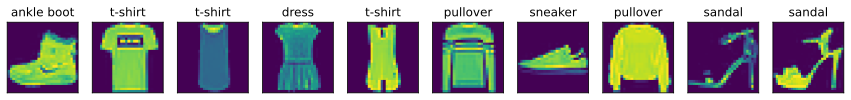

In [21]:
def show_images(imgs, num_rows, num_cols, titles=None, scale=1.5):
    figsize = (num_cols * scale, num_rows * scale)
    _, axes = d2l.plt.subplots(num_rows, num_cols, figsize=figsize)
    axes = axes.flatten()
    for i, (ax, img) in enumerate(zip(axes, imgs)):
        if torch.is_tensor(img):
            ax.imshow(img.numpy())
        else:
            ax.imshow(img)
        ax.axes.get_xaxis().set_visible(False)
        ax.axes.get_yaxis().set_visible(False)
        if titles:
            ax.set_title(titles[i])

X, y = next(iter(data.DataLoader(mnist_train, batch_size=10)))
show_images(X.reshape(10, 28, 28), 1, 10, titles=get_fm_labels(y))

#### 小批量样本读取
使用内部迭代器可以从总体样本中随机抽取一部分样本

In [22]:
batch_size = 256

train_iter = data.DataLoader(mnist_train, batch_size, shuffle=True, num_workers=0)
# 最后一个参数是用来规定读取数据的线程数的

timer = d2l.Timer()
for X, y in train_iter: # 每次从迭代器随机取batch_size个样本给X、y，
                        # 且多次循环遍历完样本集，不重不漏
    continue
print(f'{timer.stop():.2f} s.')

2.35 s.


## Softmax 回归从零实现
#### 初始化模型参数
对于我们需要训练的模型而言，每个样本的输入是一个 $1 \times 28 \times 28=28^2$ 的图像，可以视为一个长度为 $28^2 = 784$ 的行向量；输出是十个类别，因此构成了一个 $\mathbf{Y} = \mathbf{wX} + \mathbf{b}$ 的方程组，其中w是一个$10\times784$的矩阵，而b是一个10的行向量（torch的方程组与线代的方程组呈转置关系）。同之前一样，首先使用正态分布初始化w。

In [23]:
from IPython import display

batch_size = 256
# train_iter已经在前文手动自定义，test_iter使用d2l自带的迭代器定义
_, test_iter = d2l.load_data_fashion_mnist(batch_size)

num_inputs = 28 * 28
num_outputs = 10

W = torch.normal(0, 0.01, size=(num_inputs, num_outputs), requires_grad=True)
b = torch.zeros(num_outputs, requires_grad=True)

#### 定义Softmax操作
##### torch.sum()的细节
如果不用参数管理，sum会直接把张量全部累加并退化成一个标量（0维张量）。在dl训练中，sum有两个常用的参数，即`torch.sum(d, keeepdim=bool)`
`d`：求和的维度，sum会沿着这个途径求和，把张量压缩到n-1维
`keepdim`是否保留求和的维度，如果为`False`，张量维度就真的变成了n-1维了。考虑到广播机制，可以把该参数设为`True`，此时张量维度不变，只是求和维度的长度从k变为1。

##### Softmax的实现流程
$$ \mathrm{softmax}(\mathbf{X})_{ij} = \frac{\exp(\mathbf{X}_{ij})}{\sum_k \exp(\mathbf{X}_{ik})}. $$

根据这个公式，我们在处理的时候需要考虑
1. 使用exp对每个项求幂
2. 对每一行求和（分母，规范化常数）
3. 相除

In [24]:
def softmax_f(X):
    X_e = torch.exp(X)
    partition = X_e.sum(1, keepdim=True)
    return X_e / partition 

事实上该代码存在部分问题，如某元素$k$比较大的时候，带入$e^k$会直接溢出。一般情况可以根据下面等式区消除
$$ \frac{\exp{(X_j)}}{\sum{exp{(o_k)}}} = \frac{\exp{(X_j-c)}}{\sum{exp{(o_k-c)}}} $$
因此实际操作的时候只需要让c取o的最大值并带入上述等式即可

In [25]:
def softmax(X):
    X = X - X.max(1, keepdim=True).values
    X_e = torch.exp(X)
    partition = X_e.sum(1, keepdim=True)
    return X_e / partition 

def net(X):
    return softmax(torch.matmul(X.reshape((-1, W.shape[0])), W) + b)

#### 定义损失函数
回顾交叉熵函数
$$l(\mathbf{y}, \hat{\mathbf{y}}) = - \sum_{j=1}^q y_j \log \hat{y}_j$$
对于我们目前解决的单分类问题，独热编码只有一个维度为1，其他全部为0。考虑到0的性质，实际上上式直接被简化为$-log{(\hat{y}_k)}$，其中k就是独热编码为1的那个分类。
因此代码直接简化为：


In [26]:
def cross_entropy(y_hat, y):
    return -torch.log(y_hat[range(len(y_hat)), y])

#### 分类精度
对于硬分类，几乎一定会存在分类对了的和分类错了的。计算这个比值，我们就可以直观看到模型的能力。
不过，精度本身的离散化不可导的，因此分类精度仅限于供人类评估用。实际调整模型还得依靠优化函数等。

In [27]:
def accuracy(y_hat, y):
    '''这个函数负责针对某批样本输出有效样本数'''
    if len(y_hat.shape) > 1 and y_hat.shape[1] > 1: # 确定是一个有效维度大于2的张量
        y_hat = y_hat.argmax(axis=1)                # y_hat未取argmax，取一下确定分类情况           
    cmp = y_hat.type(y.dtype) == y                  # 逐个比较样本，获取整个样本集的比较情况（一个bool向量）
    return float(cmp.type(y.dtype).sum())           # 返回最终的有效样本数量，float可以确保最后算比值的时候不会出问题
# 最终比值为 acc = accuracy(y_hat, y) / len(y)

def evaluate_accuracy(net, data_iter):
    '''获得模型对象和数据集，直接评测总体合格率'''
    if isinstance(net, torch.nn.Module):
        net.eval()
    metric = Accumulator(2)
    with torch.no_grad():
        for X, y in data_iter:
            metric.add(accuracy(net(X), y), y.numel())
    return metric[0] / metric[1]

class Accumulator:  #@save
    """计数器类"""
    def __init__(self, n):
        self.data = [0.0] * n
    def add(self, *args):
        self.data = [a + float(b) for a, b in zip(self.data, args)]
    def reset(self):
        self.data = [0.0] * len(self.data)
    def __getitem__(self, idx):
        return self.data[idx]

#### 训练

In [28]:
def train_epoch_ch3(net, train_iter, loss, updater):             # 参数解释，四个参数分别为模型、训练数据集、损失函数对象、模型更新函数
    '''
    这个函数已经内置在d2l包里了。
    另，这个函数是根据模型和优化
    函数来确定是否使用框架的。
    '''
    if isinstance(net, torch.nn.Module):    # 检查是否使用框架
        net.train()
    metric = Accumulator(3)                 # 3个计数器
    for X, y in train_iter:                 # 获取数据集
        y_hat = net(X)
        l = loss(y_hat, y)                  # 计算损失函数
        if isinstance(updater, torch.optim.Optimizer):     # 如果优化函数来自框架（使用框架）
            updater.zero_grad()
            l.mean().backward()             # 框架的l返回的是标量，已经是各个样本l的loss均值了，mean无意义只是统一写法
            updater.step()  
        else:
            l.sum().backward()              # 反向传播
            updater(X.shape[0])             # 手写updater
        metric.add(float(l.sum()), accuracy(y_hat, y), y.numel())   # 计数器++
    return metric[0] / metric[2], metric[1] / metric[2]

def train_ch3(net, train_iter, test_iter, loss, num_epochs, updater):
    '''正式训练'''
    animator = d2l.Animator(xlabel='epoch', xlim=[1, num_epochs], ylim=[0.3, 0.9], legend=['train loss', 'train acc', 'test acc'])          # 初始化出图对象
    for epoch in range(num_epochs):                         # 针对每个迭代周期
        train_metrics = train_epoch_ch3(net, train_iter, loss, updater) # 训练
        test_acc = evaluate_accuracy(net, test_iter)                    # 做整体评估
        animator.add(epoch + 1, train_metrics + (test_acc,))            # 画图
    train_loss, train_acc = train_metrics                       # 平均损失+训练精度
    assert train_loss < 0.5, train_loss                         # 以下三行都是断言检查
    assert train_acc <= 1 and train_acc > 0.7, train_acc        # 若不满足条件
    assert test_acc <= 1 and test_acc > 0.7, test_acc           # 则直接报错返回后者值

下面我们就可以正式设置参数开始训练了。

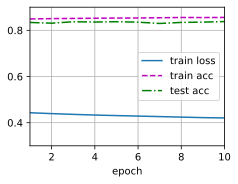

In [30]:
lr = 0.1

def updater(batch_size):
    return d2l.sgd([W, b], lr, batch_size)          # 小批量随机梯度下降

num_epochs = 10
train_ch3(net, train_iter, test_iter, cross_entropy, num_epochs, updater)

#### 预测

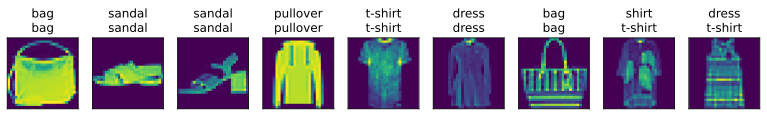

In [37]:
def pridict_ch3(net, test_iter, n=9):
    i = 0
    for X, y in test_iter:
        i += 1
        if i > 9:
            break
    trues = d2l.get_fashion_mnist_labels(y)
    preds = d2l.get_fashion_mnist_labels(net(X).argmax(axis=1))
    titles = [true + '\n' + pred for true, pred in zip(trues, preds)]
    d2l.show_images(X[0:n].reshape((n, 28, 28)), 1, n, titles=titles[0:n])

pridict_ch3(net, test_iter)